# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 17     |  |
| :-------------|:-------------|
| Amun Gomperts| 6557309 |
| Erik van den Berkmortel| 6565182 |
| Radin Asgari Eragh| 6583091 |
| Planning Groep: 17     |Tijdstip / Tijdspanne  |
|---|---|
| sanity check | 11.15 |
| condensator ontwerpen af | 11.45 |
| condensator af | 12.00 |
| condensator gemeten | 12.45 |
| Pauze 1| 12.45-13.30 |
| sensor ontwerpen af  | 14.00 |
| sensor af | 14.45 |
| Pauze 2| 14.45-15.00 |
| sensor ijken af | 16.00 |



## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def Capaciteit(A, d, epsilon):
    C = epsilon*A/d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
import numpy as np
import matplotlib.pyplot as plt

epsilon0 = 8.854e-12

C = Capaciteit(0.01, 0.001, 4*epsilon0)


print(f"Berekende capaciteit plaatcondensator groep 17 is ", round(C*1e12)," pF")


print(16-12.3)

c_test0 = Capaciteit(0.01, 0.001, 88*epsilon0)
c_test100 = Capaciteit(0.01, 0.001, 60*epsilon0)

print(c_test0, c_test100)

v_test0 = 1000*c_test0*2*np.pi*100000*8
v_test100 = 1000*c_test100*2*np.pi*100000*8

print(v_test0,v_test100)
print((2.447e-9*0.006)/(0.15*0.10)/epsilon0)



Berekende capaciteit plaatcondensator groep 17 is  354  pF
3.6999999999999993
7.79152e-09 5.312399999999999e-09
39.16445118767671 26.70303490068866
110.54890444996612


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](plaatcondensator_sanitycheck.jpeg)
![scope meting 2](Signaal_sanitycheck.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 17| 354 |1.78 | 0.2 | 39.8 |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsen.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die temperatuur meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgewerkte_schets.jpg)

[1075.74650081 1253.27223331 1534.8103308 ] F
[5.40729169 6.29963335 7.71479818] V


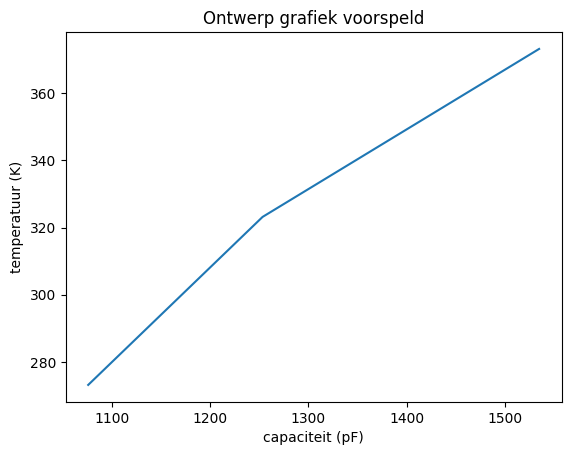

In [4]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.


dikte = 0.006
breedte = 0.1
lengte = 0.15
epsilon_min =55*epsilon0
epsilon_mid = 70.5*epsilon0
epsilon_max =88*epsilon0

def epsilon_water(T): #deze functie is de functie die de epsilon ten opzichte van temperatuur bepaald voor water.
    epsilon = (87.740-0.4*T+9.398*10**-4*T**2)*epsilon0 
    return epsilon

T_min = 273.15
T_mid = 323.15
T_max = 373.15
T = np.array([T_min, T_mid, T_max])

epsilon = epsilon_water(T)

oppervlakte = breedte * lengte
Capaciteit_sensor = Capaciteit(oppervlakte, dikte, epsilon)

print(Capaciteit_sensor*10**12,"F")
v_sensor = 1000*Capaciteit_sensor*2*np.pi*100000*8
print(v_sensor,"V") 

plt.title("Ontwerp grafiek voorspeld")
plt.plot(Capaciteit_sensor*10**12,T,"")
plt.xlabel("capaciteit (pF)")
plt.ylabel("temperatuur (K)")
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 1075 |8.4 |
| gemiddelde capaciteit| 1253 |9.6 |
| maximale capaciteit| 1534.425 |10.8 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling_sensor.jpg)
![meting 2](final_sensor.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

Text(0, 0.5, 'Temperatuur (K)')

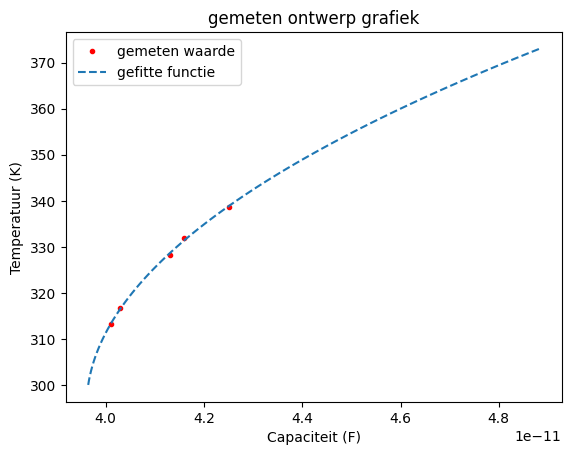

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit

gemeten_capaciteit = np.array([42.5,41.6,41.3,40.3,40.1]) * 10**-12
gemeten_temp = np.array([65.6,58.7,55,43.6,40]) + 273.15

def capaciteit_water_fit(T,a,b,c):
    return (a-b*T+c*(T**2))*epsilon0*oppervlakte/dikte

value_a, fout_a = curve_fit(capaciteit_water_fit, gemeten_temp, gemeten_capaciteit)

T_fit = np.arange(300,373.15)

plt.title("gemeten ontwerp grafiek")
plt.plot(gemeten_capaciteit, gemeten_temp, "r.", label="gemeten waarde")
plt.plot(capaciteit_water_fit(T_fit,*value_a), T_fit,"--",label="gefitte functie")
plt.legend()
plt.xlabel("Capaciteit (F)")
plt.ylabel("Temperatuur (K)")


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Hij kan beter vertikaal georienteerd zijn, dit zorgt voor minder lucht in de zakjes.
* Een niet geleidende tussen stof, die nogsteeds een epsilon heeft die sterk afhankelijk is van temperatuur.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](final_sensor_2.jpeg)

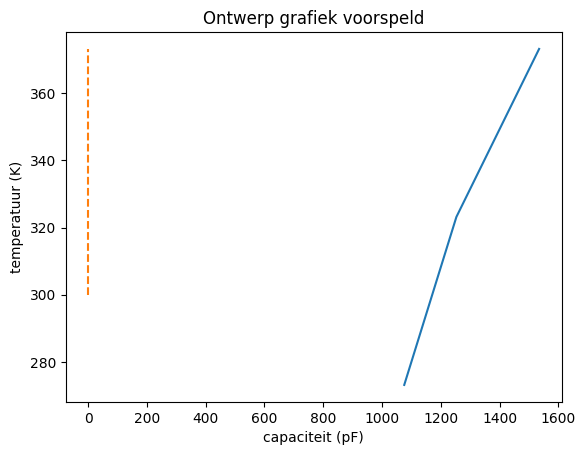

Text(0, 0.5, 'Temperatuur (K)')

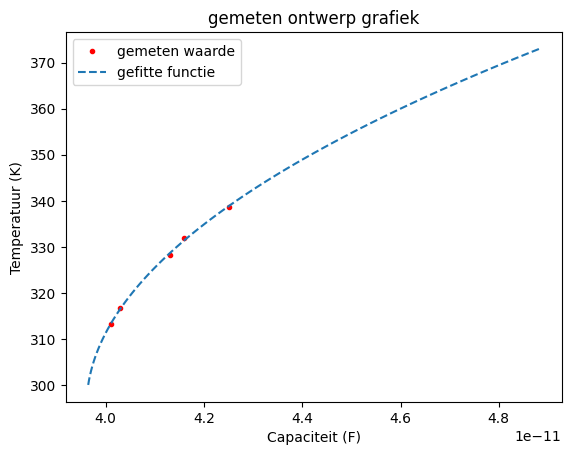

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
plt.title("Ontwerp grafiek voorspeld")
plt.plot(Capaciteit_sensor*10**12,T,"")
plt.plot(capaciteit_water_fit(T_fit,*value_a), T_fit,"--",label="gefitte functie")
plt.xlabel("capaciteit (pF)")
plt.ylabel("temperatuur (K)")
plt.show()

plt.title("gemeten ontwerp grafiek")
plt.plot(gemeten_capaciteit, gemeten_temp, "r.", label="gemeten waarde")
plt.plot(capaciteit_water_fit(T_fit,*value_a), T_fit,"--",label="gefitte functie")
plt.legend()
plt.xlabel("Capaciteit (F)")
plt.ylabel("Temperatuur (K)")


## Opdracht 10: Vul hieronder de conclusie in.

Onze opstelling kan de temperatuur meten boven 310 Kelvin. Er zit een erg groot verschill tussen de verwachte capaciteit en de gemeten capaciteit. Dit lijkt te liggen aan lucht die nog in de zakjes zat of de zakjes zelf. Dit zou beteken dat er verschillende condensatoren in serie zouden staan wat betekent dat de totale capaciteit sterk naar beneden zou gaan. In conclusie de sensor lijkt niet heel geschikt.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

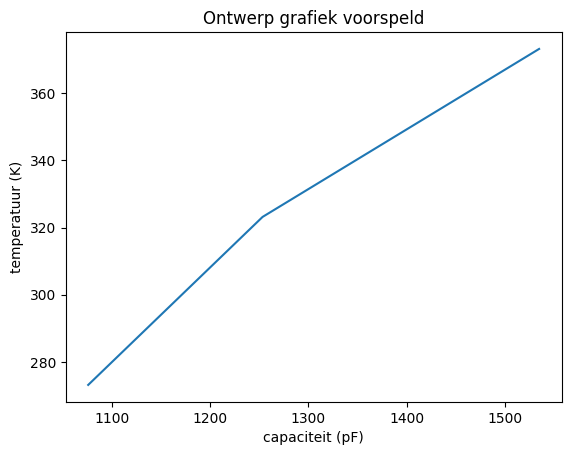

Text(0, 0.5, 'Temperatuur (K)')

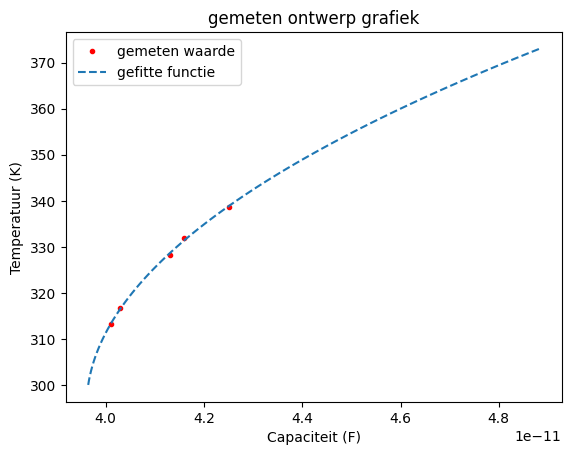

In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
plt.title("Ontwerp grafiek voorspeld")
plt.plot(Capaciteit_sensor*10**12,T,"")
plt.xlabel("capaciteit (pF)")
plt.ylabel("temperatuur (K)")
plt.show()

plt.title("gemeten ontwerp grafiek")
plt.plot(gemeten_capaciteit, gemeten_temp, "r.", label="gemeten waarde")
plt.plot(capaciteit_water_fit(T_fit,*value_a), T_fit,"--",label="gefitte functie")
plt.legend()
plt.xlabel("Capaciteit (F)")
plt.ylabel("Temperatuur (K)")


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](final_sensor_2.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

Vanwegen te weinig metingen is het niet mogelijk om uit de behaalde data een betrouwbare onzekerheid of gevoeligheid te bepalen.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 1075 |8.4 |
| gemiddelde capaciteit| 1253 |9.6 |
| maximale capaciteit| 1534.425 |10.8 |

Text(0, 0.5, 'Temperatuur (K)')

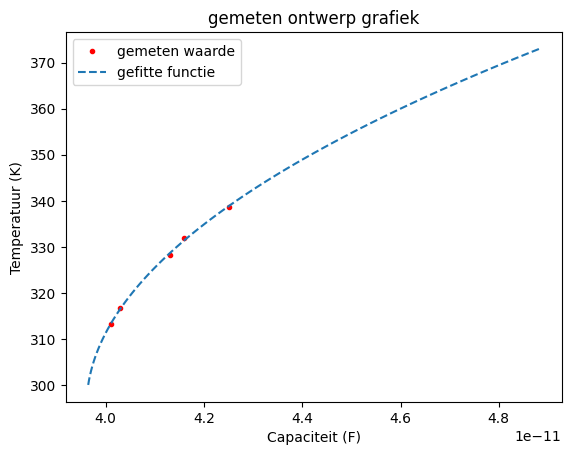

In [8]:
plt.title("gemeten ontwerp grafiek")
plt.plot(gemeten_capaciteit, gemeten_temp, "r.", label="gemeten waarde")
plt.plot(capaciteit_water_fit(T_fit,*value_a), T_fit,"--",label="gefitte functie")
plt.legend()
plt.xlabel("Capaciteit (F)")
plt.ylabel("Temperatuur (K)")
